In [4]:
import pandas as pd
from pathlib import Path

run_dir = Path("/home/rtgtx7/Desktop/AD/v-max/metrics_only/ai/data/validation.tfrecord/PPO_VEC_MLP_04-12_18:20:14/model_192532480")  # 改成你的 run 路径

csv_path = run_dir / "evaluation_episodes.csv"
df = pd.read_csv(csv_path)

# 看看有哪些列
print(df.columns)

# 按 nuplan_aggregate_score 从低到高排，取前10
worst = df.sort_values("nuplan_aggregate_score", ascending=True).head(10)

print("==== Worst 10 by nuplan_aggregate_score ====")
print(worst[[
    "scenario_index",         # 或者叫 scenario_id，看你的列名
    "nuplan_aggregate_score",
    "at_fault_collision",
    "overlap",
    "distance_into_oncoming_traffic"
]])


Index(['scenario_index', 'episode_length', 'accuracy', 'at_fault_collision',
       'comfort', 'distance_into_oncoming_traffic',
       'nuplan_driving_direction_compliance', 'log_divergence', 'offroad',
       'distance_on_multiple_lanes', 'time_on_multiple_lanes',
       'multiple_lanes_score', 'overlap', 'progress_ratio', 'making_progress',
       'run_red_light', 'sdc_off_route', 'sdc_progression', 'sdc_wrongway',
       'max_overspeed_m_per_s', 'max_overspeed_km_per_h',
       'nuplan_speed_compliance', 'min_ttc', 'average_ttc', 'ttc_within_bound',
       'nuplan_aggregate_score', 'vmax_aggregate_score'],
      dtype='object')
==== Worst 10 by nuplan_aggregate_score ====
       scenario_index  nuplan_aggregate_score  at_fault_collision  overlap  \
10024           10024                 -0.6875                 2.0      1.0   
28807           28807                 -0.6875                 2.0      1.0   
34593           34593                 -0.6875                 2.0      1.0   
118

In [5]:
print(df.columns)

# 按 nuplan_aggregate_score 从高到低排，取前 10（分数越高越好）
best = df.sort_values("nuplan_aggregate_score", ascending=False).head(10)
# 等价写法：best = df.nlargest(10, "nuplan_aggregate_score")

print("==== Best 10 by nuplan_aggregate_score ====")
print(best[[
    "scenario_index",         # 如果列名不同，比如是 "scenario_id"，这里改一下
    "nuplan_aggregate_score",
    "at_fault_collision",
    "overlap",
    "distance_into_oncoming_traffic"
]])


Index(['scenario_index', 'episode_length', 'accuracy', 'at_fault_collision',
       'comfort', 'distance_into_oncoming_traffic',
       'nuplan_driving_direction_compliance', 'log_divergence', 'offroad',
       'distance_on_multiple_lanes', 'time_on_multiple_lanes',
       'multiple_lanes_score', 'overlap', 'progress_ratio', 'making_progress',
       'run_red_light', 'sdc_off_route', 'sdc_progression', 'sdc_wrongway',
       'max_overspeed_m_per_s', 'max_overspeed_km_per_h',
       'nuplan_speed_compliance', 'min_ttc', 'average_ttc', 'ttc_within_bound',
       'nuplan_aggregate_score', 'vmax_aggregate_score'],
      dtype='object')
==== Best 10 by nuplan_aggregate_score ====
       scenario_index  nuplan_aggregate_score  at_fault_collision  overlap  \
41890           41890                     1.0                 0.0      0.0   
41891           41891                     1.0                 0.0      0.0   
41910           41910                     1.0                 0.0      0.0   
4191

In [13]:
import pandas as pd
import numpy as np
from pathlib import Path

cols = [
    "accuracy",
    "vmax_aggregate_score",
    "nuplan_aggregate_score",
    "at_fault_collision",
    "overlap",
    "distance_into_oncoming_traffic",
]

print("==== 基本统计（describe + 分位数）====")
stats = df[cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99])
print(stats)

# 如果想看每个二值/频率型指标的均值（≈发生概率）
print("\n==== 均值（可以看成发生比例）====")
print(df[cols].mean())

# 如果想看直方图分布（以 nuplan_aggregate_score 为例）
print("\n==== nuplan_aggregate_score 直方图分布 ====")
hist, bin_edges = np.histogram(df["nuplan_aggregate_score"], bins=10, range=(0, 1))
for count, left, right in zip(hist, bin_edges[:-1], bin_edges[1:]):
    print(f"[{left:.2f}, {right:.2f}): {count}")
    
print("\n==== at_fault_collision 分布 ====")
print((df["at_fault_collision"] > 0).value_counts())


==== 基本统计（describe + 分位数）====
           accuracy  vmax_aggregate_score  nuplan_aggregate_score  \
count  41920.000000          41920.000000            41920.000000   
mean       0.710806              0.668589                0.667011   
std        0.453393              0.398857                0.392459   
min        0.000000             -0.736842               -0.687500   
10%        0.000000              0.000000                0.000000   
25%        0.000000              0.429541                0.487910   
50%        1.000000              0.889043                0.875000   
75%        1.000000              0.993380                0.996093   
90%        1.000000              1.000000                1.000000   
99%        1.000000              1.000000                1.000000   
max        1.000000              1.078947                1.000000   

       at_fault_collision       overlap  distance_into_oncoming_traffic  
count        41920.000000  41920.000000                    41920.00

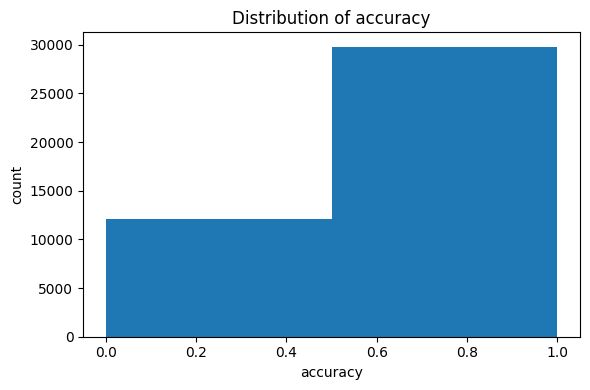

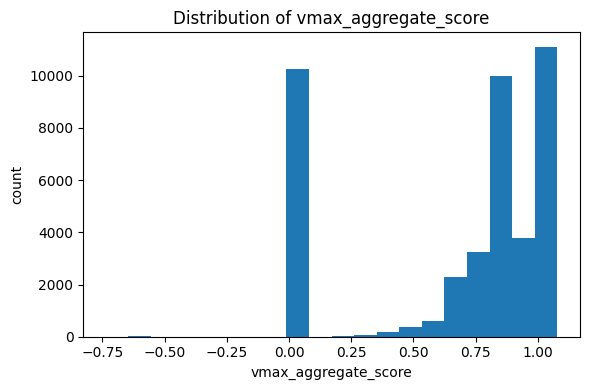

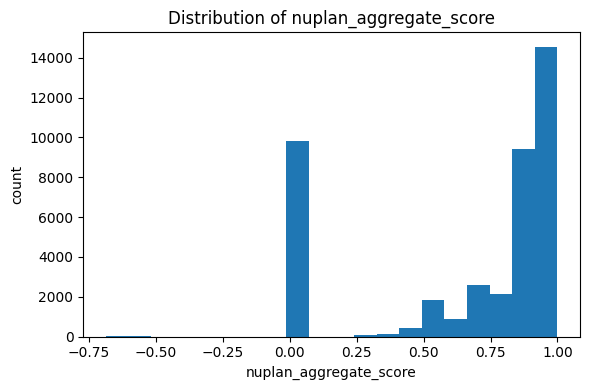

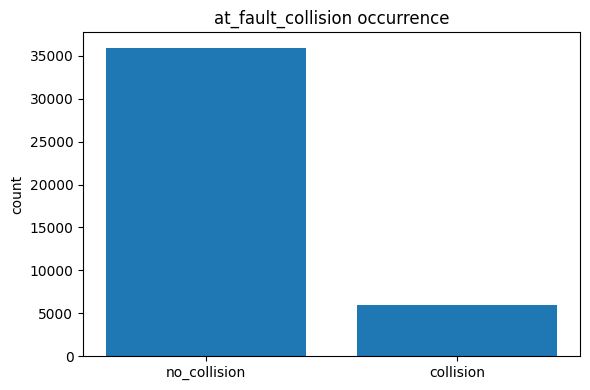

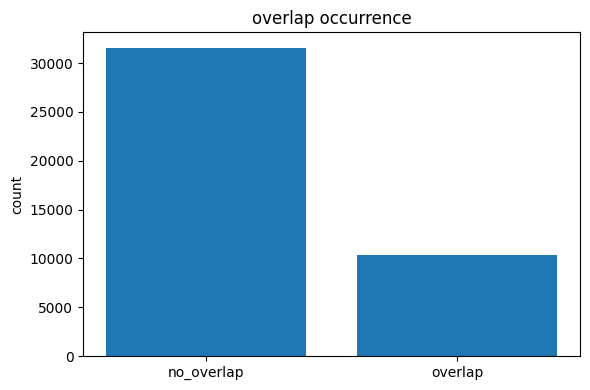

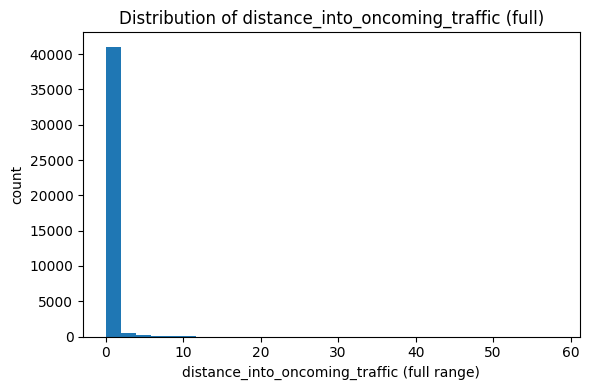

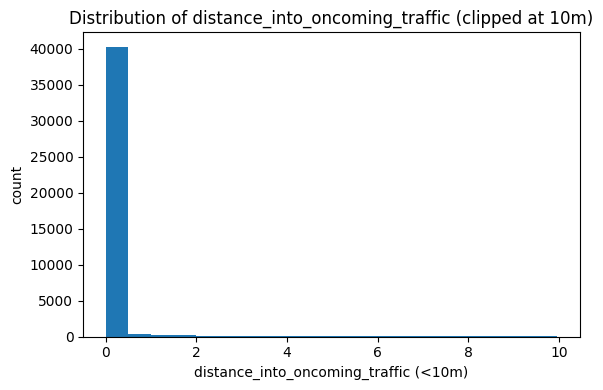

In [15]:
# ===== 1. 连续型：accuracy / vmax / nuplan =====
plt.figure(figsize=(6, 4))
plt.hist(df["accuracy"], bins=2)  # 0 或 1，给 2 个 bin 就够
plt.xlabel("accuracy")
plt.ylabel("count")
plt.title("Distribution of accuracy")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df["vmax_aggregate_score"], bins=20)
plt.xlabel("vmax_aggregate_score")
plt.ylabel("count")
plt.title("Distribution of vmax_aggregate_score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(df["nuplan_aggregate_score"], bins=20)
plt.xlabel("nuplan_aggregate_score")
plt.ylabel("count")
plt.title("Distribution of nuplan_aggregate_score")
plt.tight_layout()
plt.show()

# ===== 2. 二值/事件发生：at_fault_collision / overlap =====
# 转成 bool 再计数
collision_counts = (df["at_fault_collision"] > 0).value_counts()
plt.figure(figsize=(6, 4))
plt.bar(
    ["no_collision", "collision"],
    [collision_counts.get(False, 0), collision_counts.get(True, 0)],
)
plt.ylabel("count")
plt.title("at_fault_collision occurrence")
plt.tight_layout()
plt.show()

overlap_counts = (df["overlap"] > 0).value_counts()
plt.figure(figsize=(6, 4))
plt.bar(
    ["no_overlap", "overlap"],
    [overlap_counts.get(False, 0), overlap_counts.get(True, 0)],
)
plt.ylabel("count")
plt.title("overlap occurrence")
plt.tight_layout()
plt.show()

# ===== 3. distance_into_oncoming_traffic：先看整体，再看剪裁主区间 =====
plt.figure(figsize=(6, 4))
plt.hist(df["distance_into_oncoming_traffic"], bins=30)
plt.xlabel("distance_into_oncoming_traffic (full range)")
plt.ylabel("count")
plt.title("Distribution of distance_into_oncoming_traffic (full)")
plt.tight_layout()
plt.show()

# 由于有长尾（最大 58m），再画一张截断到 0~10m 的主区间，细节更清晰
mask = df["distance_into_oncoming_traffic"] < 10
plt.figure(figsize=(6, 4))
plt.hist(df.loc[mask, "distance_into_oncoming_traffic"], bins=20)
plt.xlabel("distance_into_oncoming_traffic (<10m)")
plt.ylabel("count")
plt.title("Distribution of distance_into_oncoming_traffic (clipped at 10m)")
plt.tight_layout()
plt.show()

In [ ]:
# Show best point from map_db/best.yaml
from pathlib import Path
import yaml

root_run_dir = Path('/home/rtgtx7/Desktop/AD/v-max/runs/PPO_VEC_MLP_05-12_11:22:58')
best_yaml = root_run_dir / 'map_db' / 'best.yaml'
if best_yaml.exists():
    best = yaml.safe_load(best_yaml.read_text())
    print('Best overrides:', best.get('ready_overrides'))
    print('Best grade:', best.get('grade_mean'))
else:
    print('best.yaml not found:', best_yaml)
